## Import Statements

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from nn.nn import NeuralNetwork
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from nn.io import read_fasta_file, read_text_file 

## Read in the fasta files for positive and negative Rap1 motif examples

In [2]:
positive_file = read_text_file('data/rap1-lieb-positives.txt')
negative_file = read_text_file('data/yeast-upstream-1k-negative.fa')

## Balance classes 

In [3]:
# create input for sample_seqs function
## Args: seqs: List[str] List of all sequences. labels: List[bool] List of positive/negative labels
seq_len = len(positive_file[0]) #17
# sliding window to generate negative control sequences of same length - randomly sample one window position
negative_seqs = []
for line in negative_file:
    if line.startswith('>'):  # skip header lines
        continue
    if len(line) >= seq_len:
        pos = np.random.randint(0, len(line) - seq_len + 1)
        negative_seqs.append(line[pos:pos + seq_len])
seqs = positive_file + negative_seqs
labels = [True] * len(positive_file) + [False] * len(negative_seqs)

## Split Before Sampling - Avoids same positives to be present in both training and validation sets

In [4]:
seqs_train, seqs_val, labels_train, labels_val = train_test_split(
    seqs, labels, test_size=0.2, random_state=42)


## Sample Training and Validation separately

In [5]:
sampled_seqs_train, sampled_labels_train = sample_seqs(seqs_train, labels_train)


## One hot encode Separately

In [6]:
X_train = one_hot_encode_seqs(sampled_seqs_train)
X_val = one_hot_encode_seqs(seqs_val)

y_train = np.array(sampled_labels_train).reshape(-1, 1)
y_val = np.array(labels_val).reshape(-1, 1)

## Generate instance of Neural Network class 

In [7]:
nn_arch =  [{'input_dim': X_train.shape[1], 'output_dim': 32, 'activation': 'relu'},
             {'input_dim': 32, 'output_dim': 16, 'activation': 'relu'},
             {'input_dim': 16, 'output_dim': 1, 'activation': 'sigmoid'}
             ]

classifier = NeuralNetwork(
    nn_arch=nn_arch,
    lr=0.01,
    seed=42,
    batch_size=200,
    epochs=1000,
    loss_function='binary_cross_entropy' 
)

## Train neural network on training data

In [8]:
train_loss, val_loss = classifier.fit(X_train, y_train, X_val, y_val)


## Plot training and validation loss by epoch

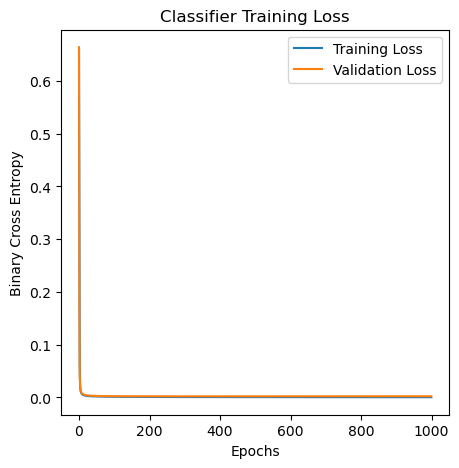

In [9]:
plt.figure(figsize=(5, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy')
plt.title('Classifier Training Loss')
plt.legend()
plt.show()

## Report the accuracy of classifier on validation dataset

In [10]:
y_pred = classifier.predict(X_val)
y_pred_binary = (y_pred > 0.5).astype(int)
accuracy = np.mean(y_pred_binary == y_val)
print("Validation accuracy:", accuracy)

# check if it's just predicting all one class
print("Predicted positives:", np.sum(y_pred_binary))
print("Predicted negatives:", np.sum(y_pred_binary == 0))
print("Actual positives:", np.sum(y_val))
print("Actual negatives:", np.sum(y_val == 0))

Validation accuracy: 0.9996288047512992
Predicted positives: 28
Predicted negatives: 10748
Actual positives: 24
Actual negatives: 10752


## Explain choice of loss function and hyperparameters

###
I chose a learning rate of 0.01 because it was what worked for the autoencoder, and this has similar structure. A batch size of 200 was chosen to balance speed and stability. The network was trained for 1000 epochs because the loss plot shows a plateau very early on likely because the Rap1 binding motif is a very distinctive pattern that the network learns quickly. The very high accuracy is likely due to the extreme class imbalance in the validation set. At first I split the data into training and validation sets after sampling to account for the disproportionate negative and positive sequences, but I realized the high accuracy could have been due to the fact that the same positive sequences were appearing in both the training and validation sets. I changed the scheme and split the data before sampling and it seems like the accuracy is still high but this could be also due to the small amount of positives in the test set. Binary cross entropy was chosen as the loss function because this is a classification task.